In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
archivo = "deposit_pouch_z.out"

z = []
deposit_proton = []
err_proton = []
deposit_all = []
err_all = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()

        if len(parts) != 6:
            continue

        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            p = float(parts[2].replace("D", "E"))
            ep = float(parts[3].replace("D", "E"))
            a = float(parts[4].replace("D", "E"))
            ea = float(parts[5].replace("D", "E"))
        except:
            continue

        z.append((z1 + z2) / 2)
        deposit_proton.append(p)
        err_proton.append(ep)
        deposit_all.append(a)
        err_all.append(ea)

z = np.array(z)
deposit_proton = np.array(deposit_proton)
err_proton = np.array(err_proton)

error_abs = deposit_proton * err_proton

In [3]:
print(f"z = {z[0]:.3f} cm")
print(f"Energía depositada = {deposit_proton[0]:.4e} MeV/source")
print(f"Error relativo = {err_proton[0]:.4f}")
print(f"Error absoluto = {error_abs[0]:.4e} MeV/source")

z = 60.680 cm
Energía depositada = 1.0353e+08 MeV/source
Error relativo = 0.0002
Error absoluto = 2.0706e+04 MeV/source


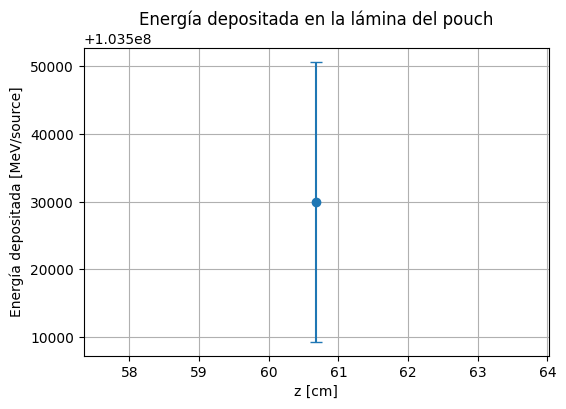

In [4]:
plt.figure(figsize=(6,4))
plt.errorbar(z, deposit_proton, yerr=error_abs, fmt="o", capsize=4)
plt.xlabel("z [cm]")
plt.ylabel("Energía depositada [MeV/source]")
plt.title("Energía depositada en la lámina del pouch")
plt.grid(True)
plt.show()

In [ ]:
# a lol esto es en todo el volumen

In [5]:
E_dep_total = 1.0353e8
N_hist = 1e9

E_dep_por_primario = E_dep_total / N_hist

print(E_dep_por_primario)

0.10353


esto es la energia que deja cada proton al entrar en el pouch, es decir, la energia que llega al pouch, no la que se deposita en el pouch. La energia depositada es menor que la energia que llega al pouch porque los protones pueden atravesar el pouch sin depositar toda su energia.  